1. 制作数据集
2. 构建模型、定义损失函数、定义优化器
3. 模型训练
4. 参数调整

In [1]:
# 首先导入包
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import torchvision.models as models
from torch.optim.lr_scheduler import CosineAnnealingLR
# This is for the progress bar.
from tqdm import tqdm
import seaborn as sns

import torchmetrics
import torchkeras 

import logging

# 配置日志（级别、格式、输出位置）
logging.basicConfig(
    level=logging.ERROR,  # 日志级别：DEBUG < INFO < WARNING < ERROR < CRITICAL
    format="%(asctime)s - %(levelname)s - %(message)s",  # 日志格式
    # handlers=[
    #     logging.FileHandler("app.log"),  # 输出到文件
    #     logging.StreamHandler(),  # 同时输出到控制台
    # ],
)

# 记录不同级别的日志
logging.debug("这是调试信息（级别最低，默认不显示）")
logging.info("程序正常运行")
logging.warning("注意：可能存在风险")
logging.error("出错了！")
logging.critical("严重错误，程序可能崩溃")

2025-07-29 23:22:44,082 - ERROR - 出错了！
2025-07-29 23:22:44,082 - CRITICAL - 严重错误，程序可能崩溃


制作数据集

In [2]:
# 看看label文件长啥样
abs_path = os.path.abspath("./classify-leaves.ipynb")
print(abs_path)


# data/classify-leaves
data_dir = abs_path.split("实战")[0] + "data/classify-leaves/"
print(data_dir)

labels_dataframe = pd.read_csv(data_dir + "train.csv")
print(labels_dataframe.head(5))

# 把label文件排个序
# 统计每个标签的出现次数，并按次数降序排列
label_counts = labels_dataframe["label"].value_counts()
# 提取排序后的标签列表（按出现次数从多到少）
leaves_labels = label_counts.index.tolist()
n_classes = len(leaves_labels)
print(n_classes)
print(leaves_labels[:10])
# 把label转成对应的数字
class_to_num = dict(zip(leaves_labels, range(n_classes)))
class_to_num
# 再转换回来，方便最后预测的时候使用
num_to_class = {v: k for k, v in class_to_num.items()}

/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/实战/c2/classify-leaves.ipynb
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/data/classify-leaves/
          image             label
0  images/0.jpg  maclura_pomifera
1  images/1.jpg  maclura_pomifera
2  images/2.jpg  maclura_pomifera
3  images/3.jpg  maclura_pomifera
4  images/4.jpg  maclura_pomifera
176
['maclura_pomifera', 'ulmus_rubra', 'prunus_virginiana', 'acer_rubrum', 'broussonettia_papyrifera', 'prunus_sargentii', 'ptelea_trifoliata', 'ulmus_pumila', 'abies_concolor', 'asimina_triloba']


In [3]:

class LeavesDataset(Dataset):

    def __init__(
        self,
        csv_path,
        file_path,
        mode="train",
        valid_ratio=0.2,
    ):
        """
        Args:
            csv_path (string): csv 文件路径
            img_path (string): 图像文件所在路径
            mode (string): 训练模式还是测试模式
            valid_ratio (float): 验证集比例
        """


        self.file_path = file_path
        self.mode = mode

        self.labels_dataframe = pd.read_csv(csv_path,header=0)
        self.data_length = len(self.labels_dataframe)
        self.train_length = int(self.data_length * (1 - valid_ratio))

        if self.mode == "train":
            self.train_image= self.labels_dataframe.iloc[:self.train_length, 0].values
            self.train_label = self.labels_dataframe.iloc[:self.train_length, 1].values

            self.image_array= self.train_image
            self.label_array = self.train_label
        elif self.mode == "valid":
            self.valid_image = self.labels_dataframe.iloc[self.train_length :, 0].values
            self.valid_label = self.labels_dataframe.iloc[self.train_length:, 1].values

            self.image_array = self.valid_image
            self.label_array = self.valid_label
        else:# mode == "test"
            self.test_image = self.labels_dataframe.iloc[:, 0].values
            self.image_array = self.test_image

        self.real_length = len(self.image_array)

        print('Finished reading the {} set of Leaves Dataset ({} samples found)'
              .format(mode, self.real_length))

    def __len__(self):
        return self.real_length

    def __getitem__(self, index):
        image = self.image_array[index]
        label = self.label_array[index]
        logging.info(f"Processing image: {image}, label: {label}")
        image = Image.open(os.path.join(self.file_path, image)).convert("RGB")

        # 这里可以添加数据增强
        if self.mode == 'train':
            transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),   #随机水平翻转 选择一个概率
            transforms.ToTensor()
            ])
        else:
            # valid和test不做数据增强
            transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
            ])
        image = transform(image)
        label = class_to_num[label] 
        return image, label

In [4]:
train_path = data_dir + "train.csv"
test_path = data_dir + "test.csv"
# csv文件中已经images的路径了，因此这里只到上一级目录
img_path = data_dir

train_dataset = LeavesDataset(train_path, img_path, mode="train")
val_dataset = LeavesDataset(train_path, img_path, mode="valid")
test_dataset = LeavesDataset(test_path, img_path, mode="test")
print(train_dataset)
print(val_dataset)
print(test_dataset)

Finished reading the train set of Leaves Dataset (14682 samples found)
Finished reading the valid set of Leaves Dataset (3671 samples found)
Finished reading the test set of Leaves Dataset (8800 samples found)


In [5]:
# 定义data loader
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=8, shuffle=False, num_workers=5
)

val_loader = torch.utils.data.DataLoader(
    dataset=val_dataset, batch_size=8, shuffle=False, num_workers=5
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=8, shuffle=False, num_workers=5
)

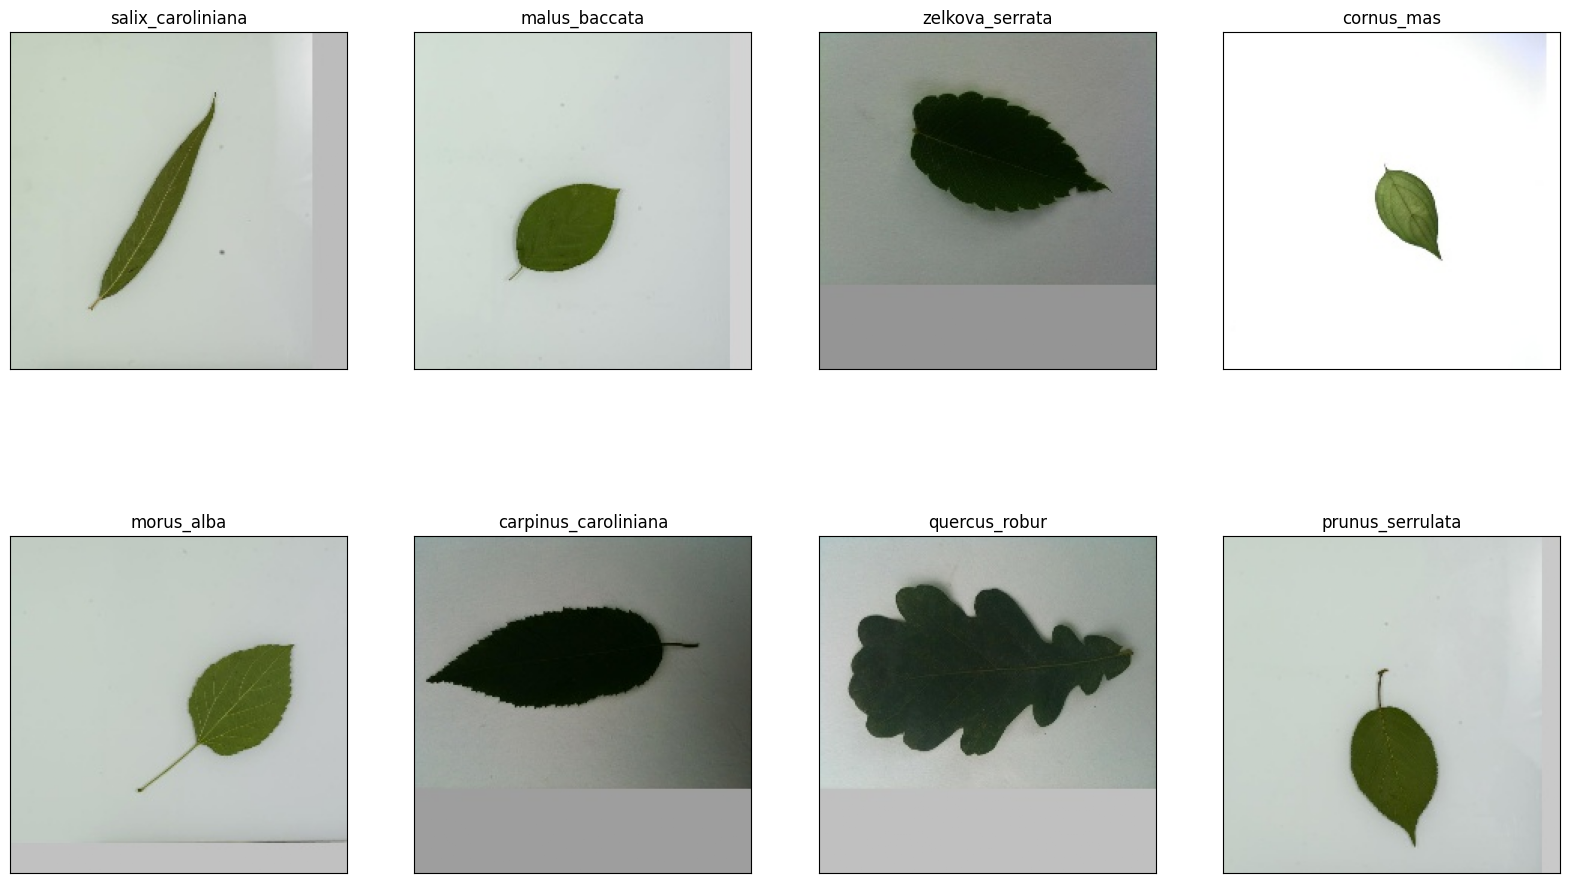

In [6]:
# 给大家展示一下数据长啥样
def im_convert(tensor):
    """展示数据"""

    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1, 2, 0)
    image = image.clip(0, 1)

    return image


fig = plt.figure(figsize=(20, 12))
rows = 2
columns = 4

dataiter = iter(val_loader)
inputs, classes = next(dataiter)

for idx in range(columns * rows):
    ax = fig.add_subplot(rows, columns, idx + 1, xticks=[], yticks=[])
    ax.set_title(num_to_class[int(classes[idx])])
    plt.imshow(im_convert(inputs[idx]))
plt.show()

构建模型

In [7]:
def get_net():
    num_to_class=176
    net=models.resnet34(pretrained=True)
    # 修改最后一层的输出为分类数
    net.fc = nn.Linear(net.fc.in_features, num_to_class)
    # 冻结非分类头的参数
    for param in net.parameters():
        param.requires_grad = False
    # 只训练分类头的参数
    for param in net.fc.parameters():
        param.requires_grad = True
    # 打印网络结构
    logging.info("Network structure:\n{}".format(net))
    return net


class Accuracy(nn.Module):
    def __init__(self):
        super().__init__()

        self.correct = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        self.total = nn.Parameter(torch.tensor(0.0), requires_grad=False)

    def forward(self, preds: torch.Tensor, targets: torch.Tensor):
        preds = preds.argmax(dim=-1)
        m = (preds == targets).sum()
        n = targets.shape[0]
        self.correct += m
        self.total += n

        return m / n

    def compute(self):
        return self.correct.float() / self.total

    def reset(self):
        self.correct -= self.correct
        self.total -= self.total

使用torchkeras进行模型训练、调参

/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<<<<<< ⚡️ cuda is used >>>>>>


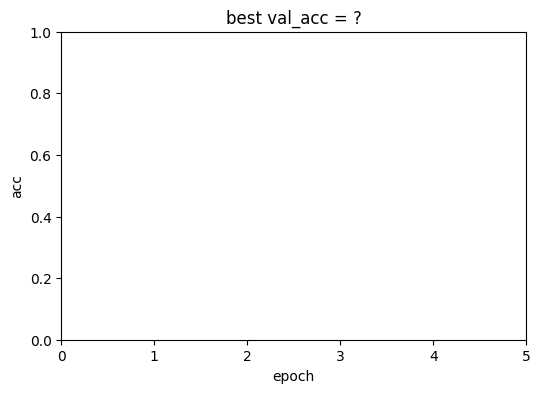

KeyboardInterrupt: 

In [ ]:
net = get_net().to("cuda" if torch.cuda.is_available() else "cpu")



model = torchkeras.KerasModel(
    net,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(net.parameters(), lr=3e-4),
    metrics_dict={"acc": Accuracy()},
)

# if gpu/mps is available, will auto use it, otherwise cpu will be used.
ckpt_path = "checkpoint"
# model.load_ckpt(ckpt_path) #load trained ckpt and continue training
dfhistory = model.fit(
    train_data=train_loader,
    val_data=val_loader,
    epochs=5,
    patience=3,
    monitor="val_acc",
    mode="max",
    ckpt_path=ckpt_path,
    plot=True,
)